In [ ]:
import os
import kagglehub
print("Download Successful! Your Titanic data is stored at: ",kagglehub.competition_download("titanic"))

Download Successful! Your Titanic data is stored at:  C:\Users\Madhav Sharma\.cache\kagglehub\competitions\titanic


In [10]:
from pathlib import Path
import pandas as pd
CACHE_DIR = Path.home()
csv_path = CACHE_DIR / '.cache/kagglehub/competitions/titanic/train.csv'
train_df = pd.read_csv(csv_path)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
train_df.info()
train_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Text(0.5, 1.0, 'Survival rates by Class and Gender')

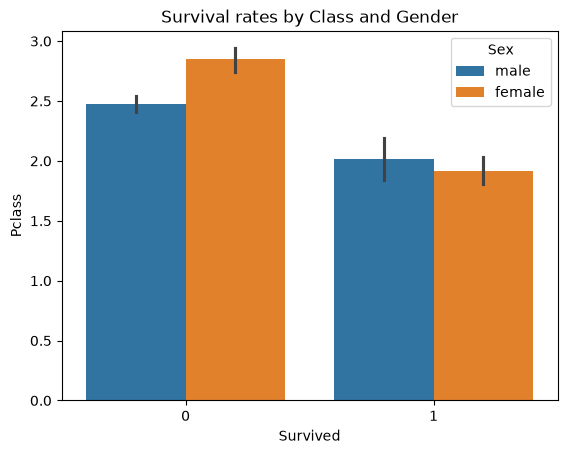

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.barplot(data=train_df,x='Survived',y='Pclass',hue='Sex')
plt.title('Survival rates by Class and Gender')


Text(0.5, 1.0, 'Number of people of Diffrent Age Groups')

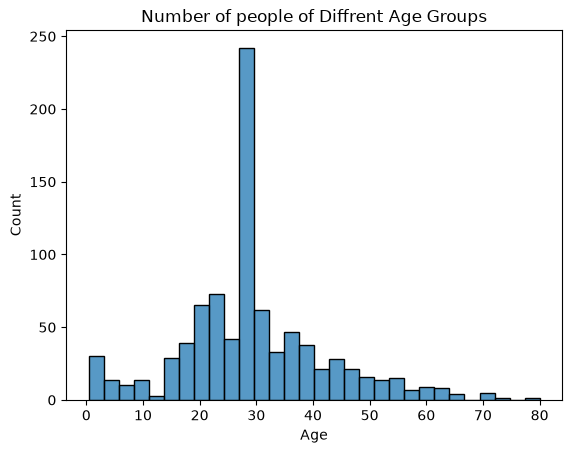

In [32]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
sns.histplot(data=train_df,x='Age')
plt.title("Number of people of Diffrent Age Groups")

Text(0.5, 1.0, 'Fare Distribution by class')

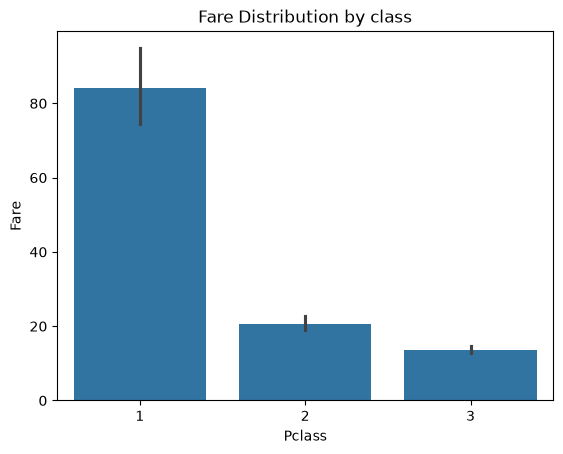

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.barplot(data=train_df,x='Pclass',y='Fare')
plt.title("Fare Distribution by class")

Text(0.5, 1.0, 'Correlation Heatmap')

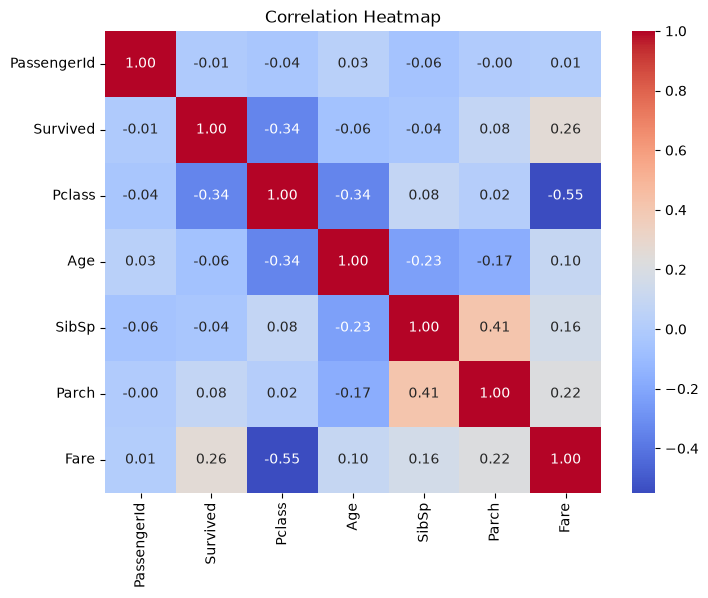

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = train_df.select_dtypes(include='number')
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

##Here are some of the insights we can conclude from this data

#From the barplot graph of Survival Rates by Class and Gender
 
- Women had a significantly higher survival rate than men across all classes , as indicated 
   by the much longer orange bars under the Survived = 1.0 section
- Men made up the vast majority of those who did not survive visible by the dominant blue bars
   under the Survived = 0.0 section
- Lower passanger classes especially class 3.0 show a much higher concentration of non-survivors
   compared to upper classes , reflecting that the higher class passengers were prioritized during
   evacuation

#From the Number of people of diffrent age groups Histogram

- The vast majority of the population is concentrated between 15 and 40 years old.
- The data is positively skewed, meaning there are far fewer older individuals 
   (ages 50–80) than younger ones.
- There is a small but notable spike at the very beginning of the axis 
   (ages 0–5), showing a distinct group of infants and young toddlers.

#From the Fare Distribution by Class Bar plot

- There is a massive wealth gap between first class and the other two classes. 
   First-class passengers paid roughly 4 to 5 times more on average than second
   and third-class passengers.
- The long black line (error bar) on the Class 1 bar indicates high price 
   variability. This shows that "First Class" wasn't a single flat rate 
   it included standard first-class cabins as well as ultra-luxury suites
   (like the ones booked by millionaires) that cost significantly more.
- Class 2 and Class 3 have very short error bars. This means their ticket prices
   were highly standardized and tightly clustered around a low, fixed price point.
- The average fare difference between second class (around 20) and third class 
   (around 13) is relatively small compared to the massive jump to first class.
And at the end we have a Correlation Map in the form of a Heatmap
